In [1]:
!pip -q install scikit-image scikit-learn pandas matplotlib seaborn joblib

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.semi_supervised import LabelSpreading
from sklearn.decomposition import PCA, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    adjusted_rand_score,
    normalized_mutual_info_score
)

DATASET_PATH = "/content/drive/MyDrive/Pattern_Analysis_Image_Dataset"
OUTPUT_PATH = "/content/drive/MyDrive/CSE25029_Assignment_4_Output"

os.makedirs(OUTPUT_PATH, exist_ok=True)

for folder in [
    "KMeans",
    "KMedoids",
    "GMM",
    "Supervised_Unsupervised",
    "Bayesian",
    "KNN",
    "ANN",
    "Semi_Supervised",
    "Dimensionality_Reduction",
    "Complete_System"
]:
    os.makedirs(os.path.join(OUTPUT_PATH, folder), exist_ok=True)

print("Dataset:", DATASET_PATH)
print("Output:", OUTPUT_PATH)

Dataset: /content/drive/MyDrive/Pattern_Analysis_Image_Dataset
Output: /content/drive/MyDrive/CSE25029_Assignment_4_Output


In [3]:
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp"]

image_paths = []

for extension in image_extensions:
    image_paths.extend(
        glob.glob(os.path.join(DATASET_PATH, "**", extension), recursive=True)
    )

image_paths = sorted(image_paths)

if len(image_paths) == 0:
    raise FileNotFoundError("No images were found in the dataset folder.")

records = []

for path in image_paths:
    relative_path = os.path.relpath(path, DATASET_PATH)
    parts = relative_path.split(os.sep)

    if len(parts) > 1:
        label = parts[0]
    else:
        label = os.path.splitext(os.path.basename(path))[0]

    records.append([path, label])

data = pd.DataFrame(records, columns=["path", "class"])

label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["class"])

class_names = list(label_encoder.classes_)
n_classes = len(class_names)

print("Total images:", len(data))
print("Number of classes:", n_classes)
print("Classes:", class_names)

class_counts = data["class"].value_counts().sort_index()
print("\nImages per class:")
print(class_counts)

class_counts.to_csv(
    os.path.join(OUTPUT_PATH, "class_distribution.csv")
)

Total images: 92
Number of classes: 2
Classes: ['classes', 'unlabeled_examples']

Images per class:
class
classes               80
unlabeled_examples    12
Name: count, dtype: int64


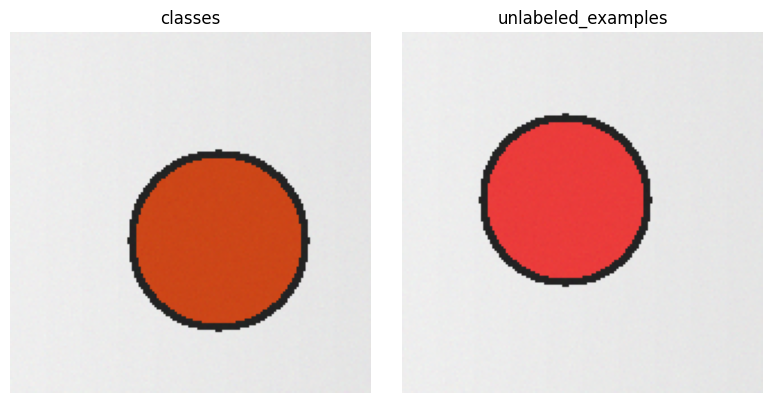

In [4]:
samples = data.groupby("class", group_keys=False).head(1)

fig, axes = plt.subplots(
    1,
    len(samples),
    figsize=(4 * len(samples), 4)
)

if len(samples) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, samples.iterrows()):
    image = Image.open(row["path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(row["class"])
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PATH, "dataset_samples.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [5]:
def extract_features(path):
    image = Image.open(path).convert("RGB")
    image = np.array(image)

    image_resized = resize(
        image,
        (128, 128),
        anti_aliasing=True
    )

    gray = rgb2gray(image_resized)

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    color_features = []

    for channel in range(3):
        histogram, _ = np.histogram(
            image_resized[:, :, channel],
            bins=16,
            range=(0, 1),
            density=True
        )
        color_features.extend(histogram)

    gray_features = [
        np.mean(gray),
        np.std(gray),
        np.min(gray),
        np.max(gray),
        np.percentile(gray, 25),
        np.percentile(gray, 50),
        np.percentile(gray, 75)
    ]

    return np.concatenate([
        hog_features,
        np.array(color_features),
        np.array(gray_features)
    ])

features = []

for path in data["path"]:
    features.append(extract_features(path))

X = np.array(features)
y = data["label"].values

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

np.save(
    os.path.join(OUTPUT_PATH, "image_features.npy"),
    X
)

np.save(
    os.path.join(OUTPUT_PATH, "image_labels.npy"),
    y
)

data.to_csv(
    os.path.join(OUTPUT_PATH, "image_metadata.csv"),
    index=False
)

Feature matrix shape: (92, 8155)
Labels shape: (92,)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    os.path.join(OUTPUT_PATH, "feature_scaler.pkl")
)

print("Standardized feature matrix:", X_scaled.shape)

Standardized feature matrix: (92, 8155)


Explained variance ratio: [0.06066227 0.04465353]
Total explained variance: 0.10531580669018324


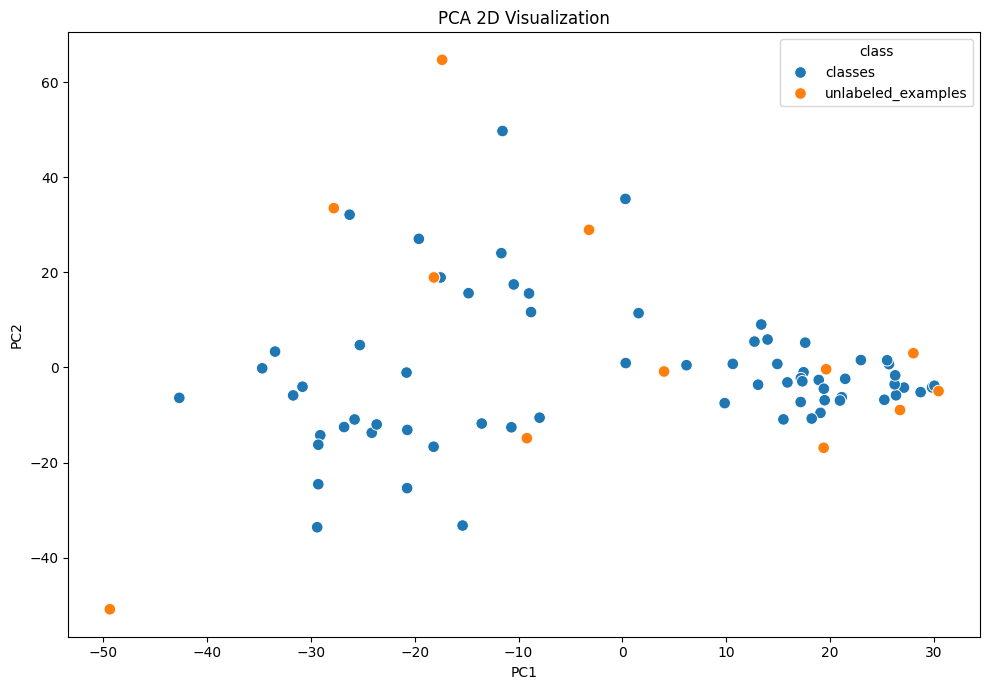

In [7]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_variance = pca_2d.explained_variance_ratio_

print("Explained variance ratio:", pca_variance)
print("Total explained variance:", pca_variance.sum())

pca_visualization = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "class": data["class"].values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_visualization,
    x="PC1",
    y="PC2",
    hue="class",
    palette="tab10",
    s=70
)
plt.title("PCA 2D Visualization")
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Dimensionality_Reduction",
        "PCA_2D.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_centers = kmeans.cluster_centers_

kmeans_ari = adjusted_rand_score(y, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y, kmeans_labels)

print("K-Means ARI:", kmeans_ari)
print("K-Means NMI:", kmeans_nmi)

kmeans_results = pd.DataFrame({
    "Actual_Class": data["class"],
    "Actual_Label": y,
    "KMeans_Cluster": kmeans_labels
})

kmeans_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "KMeans",
        "kmeans_assignments.csv"
    ),
    index=False
)

np.save(
    os.path.join(
        OUTPUT_PATH,
        "KMeans",
        "kmeans_centroids.npy"
    ),
    kmeans_centers
)

K-Means ARI: -0.006865443985014481
K-Means NMI: 0.0014455552040126913


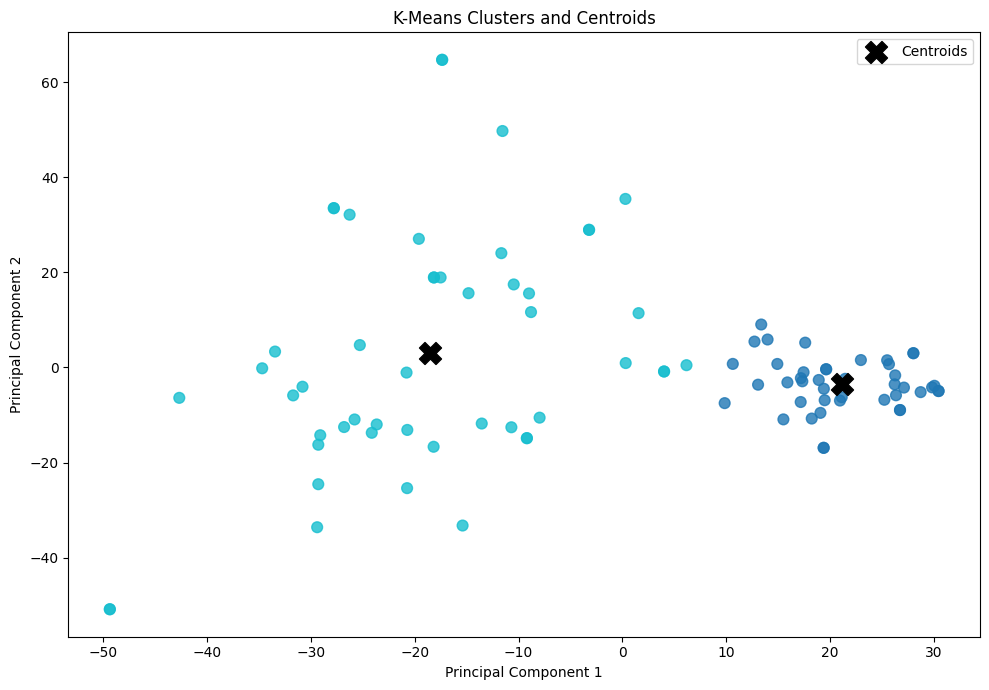

In [9]:
centers_2d = pca_2d.transform(kmeans_centers)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmeans_labels,
    cmap="tab10",
    s=60,
    alpha=0.8
)

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    marker="X",
    s=250,
    c="black",
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters and Centroids")
plt.legend()

plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "KMeans",
        "kmeans_clusters_centroids.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

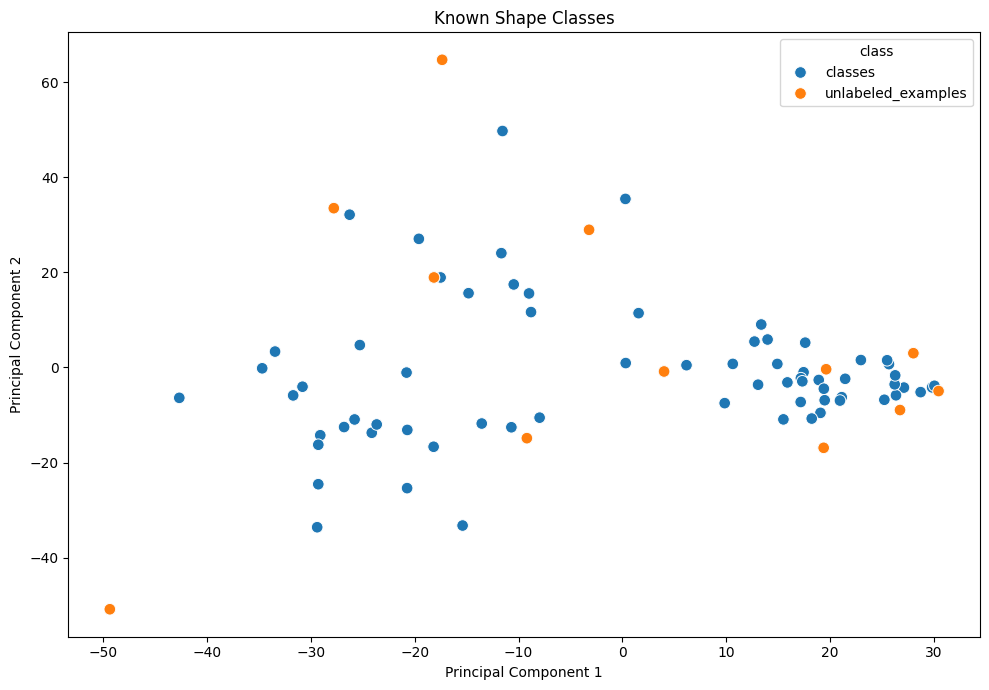

In [10]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=data["class"],
    palette="tab10",
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Known Shape Classes")
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "KMeans",
        "known_shape_classes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

kmeans_comparison = pd.DataFrame({
    "Metric": ["Adjusted Rand Index", "Normalized Mutual Information"],
    "Value": [kmeans_ari, kmeans_nmi]
})

kmeans_comparison.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "KMeans",
        "kmeans_comparison.csv"
    ),
    index=False
)

In [11]:
#TASK 2 — K-MEDOIDS

In [12]:
from sklearn.metrics import pairwise_distances

def kmedoids(X, n_clusters, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]
    medoids = rng.choice(
        n_samples,
        size=n_clusters,
        replace=False
    )

    distances = pairwise_distances(X)

    for _ in range(max_iter):
        labels = np.argmin(
            distances[:, medoids],
            axis=1
        )

        new_medoids = medoids.copy()

        for cluster in range(n_clusters):
            members = np.where(labels == cluster)[0]

            if len(members) == 0:
                continue

            cluster_distances = distances[
                np.ix_(members, members)
            ]

            costs = cluster_distances.sum(axis=1)

            new_medoids[cluster] = members[
                np.argmin(costs)
            ]

        if np.array_equal(medoids, new_medoids):
            break

        medoids = new_medoids

    labels = np.argmin(
        distances[:, medoids],
        axis=1
    )

    return labels, medoids

kmedoids_labels, medoid_indices = kmedoids(
    X_scaled,
    n_classes,
    max_iter=100,
    random_state=42
)

kmedoids_points = X_scaled[medoid_indices]

kmedoids_ari = adjusted_rand_score(
    y,
    kmedoids_labels
)

kmedoids_nmi = normalized_mutual_info_score(
    y,
    kmedoids_labels
)

print("K-Medoids ARI:", kmedoids_ari)
print("K-Medoids NMI:", kmedoids_nmi)

np.save(
    os.path.join(
        OUTPUT_PATH,
        "KMedoids",
        "medoid_indices.npy"
    ),
    medoid_indices
)

pd.DataFrame({
    "Actual_Class": data["class"],
    "KMedoids_Cluster": kmedoids_labels
}).to_csv(
    os.path.join(
        OUTPUT_PATH,
        "KMedoids",
        "kmedoids_assignments.csv"
    ),
    index=False
)

K-Medoids ARI: -0.006729394949976179
K-Medoids NMI: 0.00018744445845371883


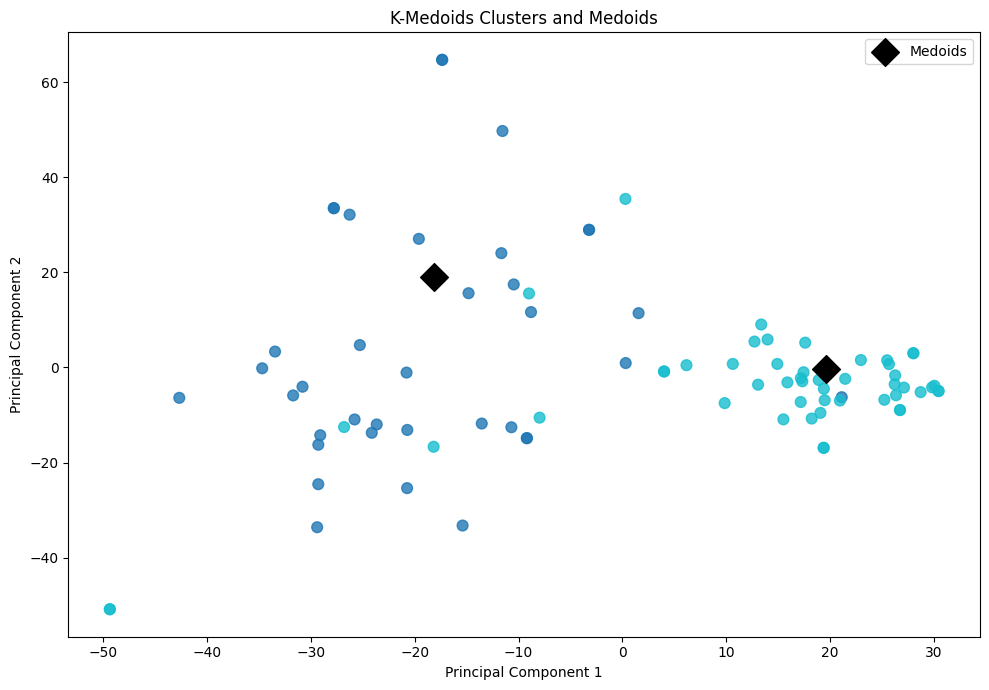

In [13]:
medoids_2d = pca_2d.transform(kmedoids_points)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmedoids_labels,
    cmap="tab10",
    s=60,
    alpha=0.8
)

plt.scatter(
    medoids_2d[:, 0],
    medoids_2d[:, 1],
    marker="D",
    s=200,
    c="black",
    label="Medoids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Medoids Clusters and Medoids")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "KMedoids",
        "kmedoids_clusters_medoids.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

      Method       ARI       NMI
0    K-Means -0.006865  0.001446
1  K-Medoids -0.006729  0.000187


<Figure size 900x600 with 0 Axes>

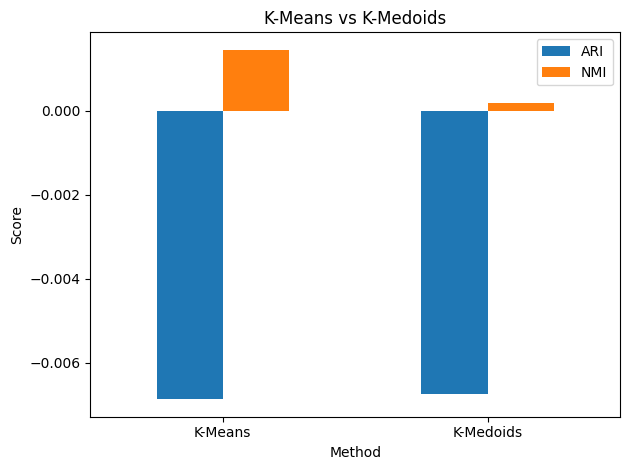

In [14]:
clustering_comparison = pd.DataFrame({
    "Method": ["K-Means", "K-Medoids"],
    "ARI": [kmeans_ari, kmedoids_ari],
    "NMI": [kmeans_nmi, kmedoids_nmi]
})

print(clustering_comparison)

clustering_comparison.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "KMedoids",
        "kmeans_vs_kmedoids.csv"
    ),
    index=False
)

plt.figure(figsize=(9, 6))

clustering_comparison.set_index("Method")[
    ["ARI", "NMI"]
].plot(kind="bar")

plt.ylabel("Score")
plt.title("K-Means vs K-Medoids")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "KMedoids",
        "kmeans_vs_kmedoids.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
#TASK 3 — GAUSSIAN MIXTURE MODEL

In [17]:
gmm = GaussianMixture(
    n_components=n_classes,
    covariance_type="diag",
    random_state=42,
    n_init=2,
    max_iter=100,
    reg_covar=1e-5
)

gmm_labels = gmm.fit_predict(X_scaled)

gmm_probabilities = gmm.predict_proba(X_scaled)

gmm_ari = adjusted_rand_score(y, gmm_labels)

gmm_nmi = normalized_mutual_info_score(y, gmm_labels)

print("GMM ARI:", gmm_ari)
print("GMM NMI:", gmm_nmi)

gmm_results = pd.DataFrame({
    "Actual_Class": data["class"],
    "GMM_Cluster": gmm_labels
})

for i in range(n_classes):
    gmm_results[f"Probability_{i}"] = gmm_probabilities[:, i]

gmm_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "GMM",
        "gmm_results.csv"
    ),
    index=False
)

joblib.dump(
    gmm,
    os.path.join(
        OUTPUT_PATH,
        "GMM",
        "gmm_model.pkl"
    )
)

print("GMM completed successfully.")

GMM ARI: -0.006865443985014481
GMM NMI: 0.0014455552040126913
GMM completed successfully.


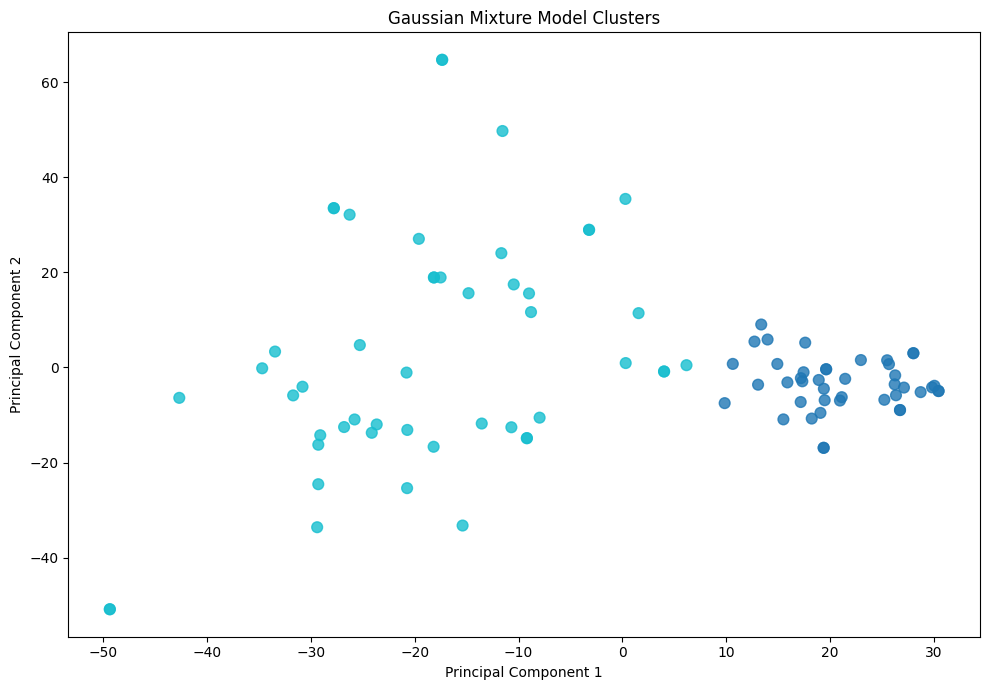

In [18]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=gmm_labels,
    cmap="tab10",
    s=60,
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Gaussian Mixture Model Clusters")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "GMM",
        "gmm_clusters.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

    Method       ARI       NMI
0  K-Means -0.006865  0.001446
1      GMM -0.006865  0.001446


<Figure size 900x600 with 0 Axes>

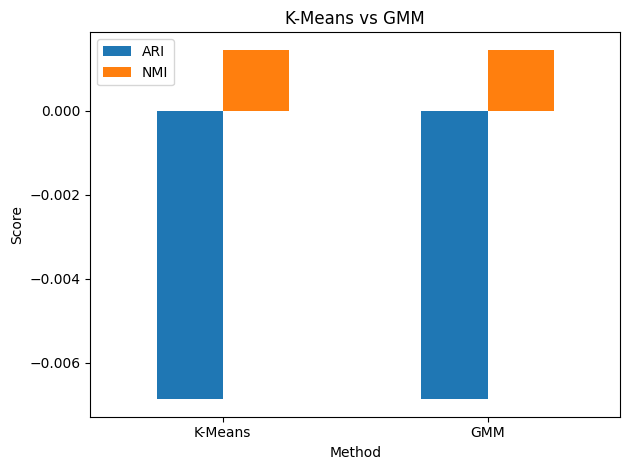

In [19]:
gmm_comparison = pd.DataFrame({
    "Method": ["K-Means", "GMM"],
    "ARI": [kmeans_ari, gmm_ari],
    "NMI": [kmeans_nmi, gmm_nmi]
})

print(gmm_comparison)

gmm_comparison.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "GMM",
        "kmeans_vs_gmm.csv"
    ),
    index=False
)

plt.figure(figsize=(9, 6))

gmm_comparison.set_index("Method")[
    ["ARI", "NMI"]
].plot(kind="bar")

plt.ylabel("Score")
plt.title("K-Means vs GMM")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "GMM",
        "kmeans_vs_gmm.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
#TASK 4 — SUPERVISED AND UNSUPERVISED LEARNING

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 73
Testing samples: 19


In [22]:
knn_supervised = KNeighborsClassifier(n_neighbors=5)

knn_supervised.fit(
    X_train,
    y_train
)

knn_predictions = knn_supervised.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

knn_precision = precision_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

supervised_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        knn_accuracy,
        knn_precision,
        knn_recall,
        knn_f1
    ]
})

print(supervised_results)

supervised_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "Supervised_Unsupervised",
        "supervised_knn_results.csv"
    ),
    index=False
)

      Metric     Value
0   Accuracy  0.894737
1  Precision  0.800554
2     Recall  0.894737
3   F1-Score  0.845029


In [23]:
test_kmeans = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=20
)

test_kmeans_labels = test_kmeans.fit_predict(X_test)

test_kmeans_ari = adjusted_rand_score(
    y_test,
    test_kmeans_labels
)

test_kmeans_nmi = normalized_mutual_info_score(
    y_test,
    test_kmeans_labels
)

supervised_unsupervised = pd.DataFrame({
    "Method": [
        "KNN Supervised",
        "K-Means Unsupervised"
    ],
    "Accuracy_or_ARI": [
        knn_accuracy,
        test_kmeans_ari
    ],
    "NMI": [
        np.nan,
        test_kmeans_nmi
    ]
})

print(supervised_unsupervised)

supervised_unsupervised.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "Supervised_Unsupervised",
        "supervised_vs_unsupervised.csv"
    ),
    index=False
)

                 Method  Accuracy_or_ARI       NMI
0        KNN Supervised         0.894737       NaN
1  K-Means Unsupervised        -0.034413  0.121901


In [24]:
#TASK 5 — BAYESIAN CLASSIFICATION

In [25]:
gnb = GaussianNB()

gnb.fit(
    X_train,
    y_train
)

gnb_predictions = gnb.predict(X_test)

gnb_accuracy = accuracy_score(
    y_test,
    gnb_predictions
)

gnb_precision = precision_score(
    y_test,
    gnb_predictions,
    average="weighted",
    zero_division=0
)

gnb_recall = recall_score(
    y_test,
    gnb_predictions,
    average="weighted",
    zero_division=0
)

gnb_f1 = f1_score(
    y_test,
    gnb_predictions,
    average="weighted",
    zero_division=0
)

gnb_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        gnb_accuracy,
        gnb_precision,
        gnb_recall,
        gnb_f1
    ]
})

print(gnb_results)

gnb_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "Bayesian",
        "gaussian_naive_bayes_results.csv"
    ),
    index=False
)

joblib.dump(
    gnb,
    os.path.join(
        OUTPUT_PATH,
        "Bayesian",
        "gaussian_naive_bayes_model.pkl"
    )
)

      Metric     Value
0   Accuracy  0.842105
1  Precision  0.795322
2     Recall  0.842105
3   F1-Score  0.818045


['/content/drive/MyDrive/CSE25029_Assignment_4_Output/Bayesian/gaussian_naive_bayes_model.pkl']

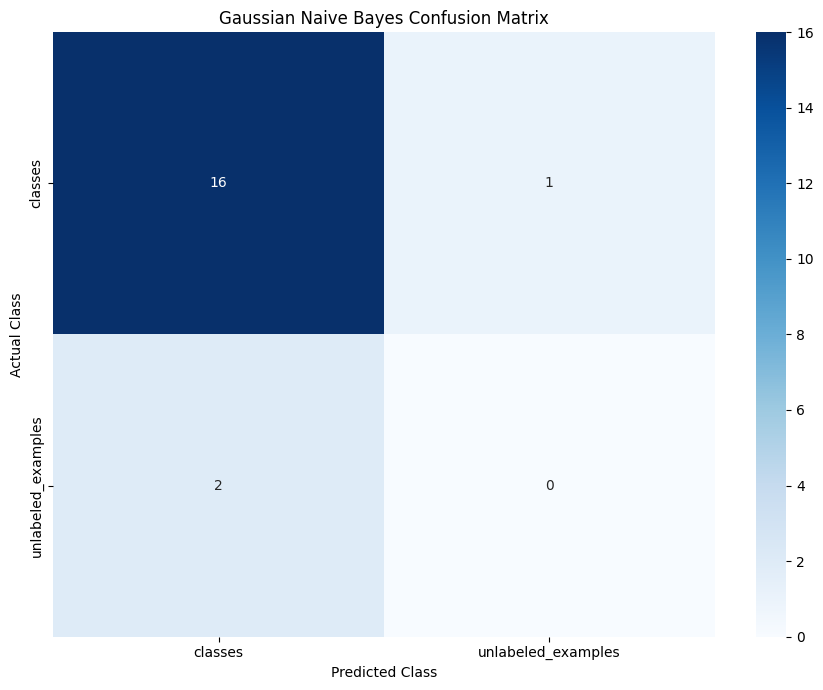

                    precision    recall  f1-score   support

           classes       0.89      0.94      0.91        17
unlabeled_examples       0.00      0.00      0.00         2

          accuracy                           0.84        19
         macro avg       0.44      0.47      0.46        19
      weighted avg       0.80      0.84      0.82        19



In [26]:
cm_gnb = confusion_matrix(
    y_test,
    gnb_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_gnb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Gaussian Naive Bayes Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Bayesian",
        "bayesian_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    classification_report(
        y_test,
        gnb_predictions,
        target_names=class_names,
        zero_division=0
    )
)

In [27]:
#TASK 6 — K-NEAREST NEIGHBOUR

Best K: 2
Best Test Accuracy: 0.8947368421052632


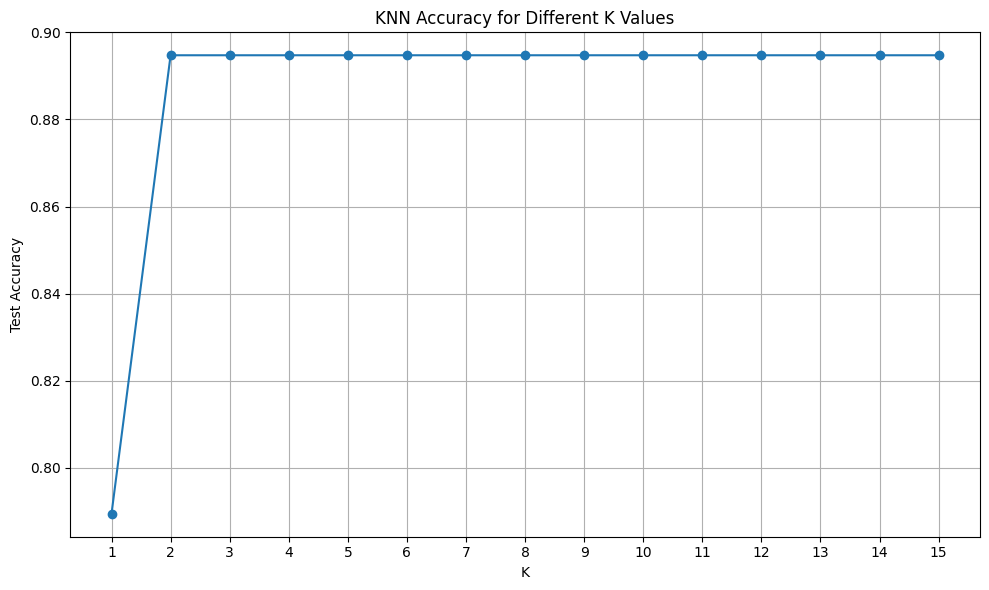

In [28]:
k_values = list(range(1, 16))
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    k_accuracies.append(accuracy)

knn_results = pd.DataFrame({
    "K": k_values,
    "Test_Accuracy": k_accuracies
})

best_index = np.argmax(k_accuracies)
best_k = k_values[best_index]
best_accuracy = k_accuracies[best_index]

print("Best K:", best_k)
print("Best Test Accuracy:", best_accuracy)

knn_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "KNN",
        "knn_k_comparison.csv"
    ),
    index=False
)

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    k_accuracies,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "KNN",
        "knn_k_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

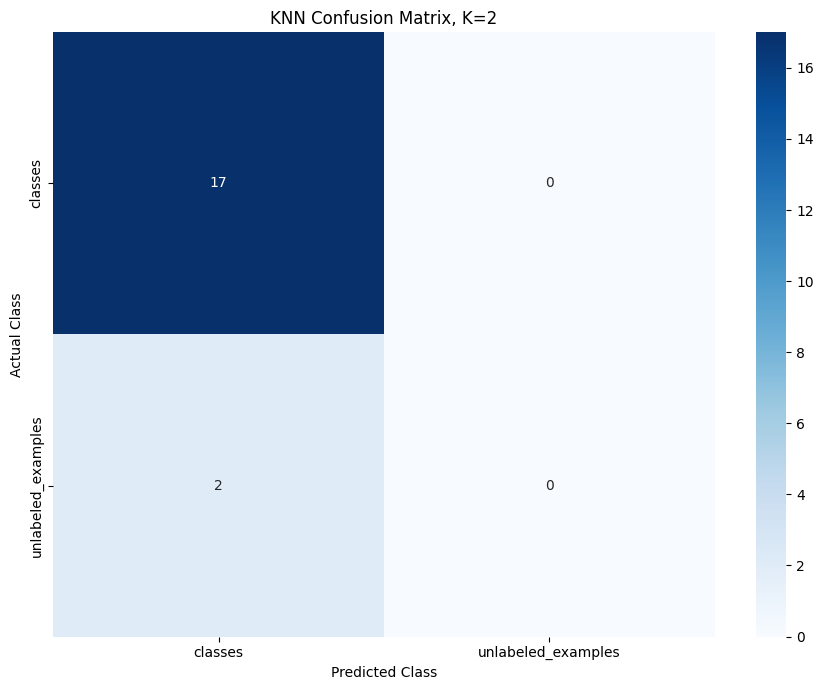

['/content/drive/MyDrive/CSE25029_Assignment_4_Output/KNN/best_knn_model.pkl']

In [29]:
best_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn.fit(
    X_train,
    y_train
)

best_knn_predictions = best_knn.predict(
    X_test
)

best_knn_cm = confusion_matrix(
    y_test,
    best_knn_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    best_knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(
    f"KNN Confusion Matrix, K={best_k}"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "KNN",
        "best_knn_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

joblib.dump(
    best_knn,
    os.path.join(
        OUTPUT_PATH,
        "KNN",
        "best_knn_model.pkl"
    )
)

In [30]:
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)

ann.fit(
    X_train,
    y_train
)

ann_predictions = ann.predict(
    X_test
)

ann_accuracy = accuracy_score(
    y_test,
    ann_predictions
)

ann_precision = precision_score(
    y_test,
    ann_predictions,
    average="weighted",
    zero_division=0
)

ann_recall = recall_score(
    y_test,
    ann_predictions,
    average="weighted",
    zero_division=0
)

ann_f1 = f1_score(
    y_test,
    ann_predictions,
    average="weighted",
    zero_division=0
)

ann_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        ann_accuracy,
        ann_precision,
        ann_recall,
        ann_f1
    ]
})

print(ann_results)

ann_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "ANN",
        "ann_results.csv"
    ),
    index=False
)

joblib.dump(
    ann,
    os.path.join(
        OUTPUT_PATH,
        "ANN",
        "ann_model.pkl"
    )
)

      Metric     Value
0   Accuracy  0.473684
1  Precision  0.732057
2     Recall  0.473684
3   F1-Score  0.575188


['/content/drive/MyDrive/CSE25029_Assignment_4_Output/ANN/ann_model.pkl']

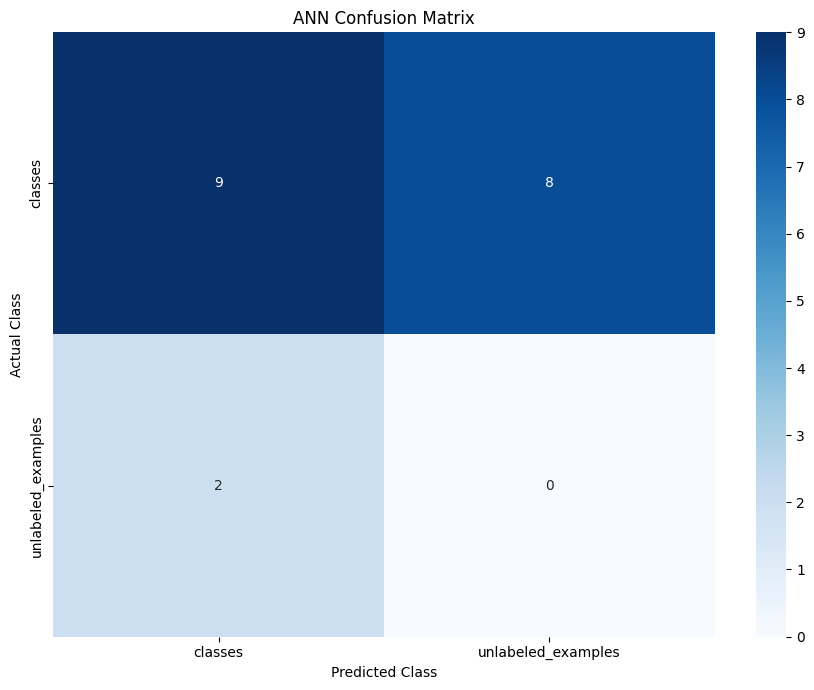

In [31]:
ann_cm = confusion_matrix(
    y_test,
    ann_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    ann_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("ANN Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "ANN",
        "ann_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
#TASK 8 — SEMI-SUPERVISED CLASSIFICATION

In [33]:
rng = np.random.default_rng(42)

y_semi = y_train.copy()

labeled_fraction = 0.20

n_labeled = max(
    n_classes,
    int(len(y_train) * labeled_fraction)
)

labeled_indices = rng.choice(
    len(y_train),
    size=n_labeled,
    replace=False
)

unlabeled_mask = np.ones(
    len(y_train),
    dtype=bool
)

unlabeled_mask[labeled_indices] = False

y_semi[unlabeled_mask] = -1

print("Total training samples:", len(y_train))
print("Labeled samples:", np.sum(y_semi != -1))
print("Unlabeled samples:", np.sum(y_semi == -1))

Total training samples: 73
Labeled samples: 14
Unlabeled samples: 59


In [34]:
label_spreading = LabelSpreading(
    kernel="rbf",
    alpha=0.2,
    max_iter=100
)

label_spreading.fit(
    X_train,
    y_semi
)

semi_predictions = label_spreading.predict(
    X_test
)

semi_accuracy = accuracy_score(
    y_test,
    semi_predictions
)

semi_precision = precision_score(
    y_test,
    semi_predictions,
    average="weighted",
    zero_division=0
)

semi_recall = recall_score(
    y_test,
    semi_predictions,
    average="weighted",
    zero_division=0
)

semi_f1 = f1_score(
    y_test,
    semi_predictions,
    average="weighted",
    zero_division=0
)

semi_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        semi_accuracy,
        semi_precision,
        semi_recall,
        semi_f1
    ]
})

print(semi_results)

semi_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "Semi_Supervised",
        "label_spreading_results.csv"
    ),
    index=False
)

joblib.dump(
    label_spreading,
    os.path.join(
        OUTPUT_PATH,
        "Semi_Supervised",
        "label_spreading_model.pkl"
    )
)

      Metric     Value
0   Accuracy  0.894737
1  Precision  0.800554
2     Recall  0.894737
3   F1-Score  0.845029


/usr/local/lib/python3.13/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


['/content/drive/MyDrive/CSE25029_Assignment_4_Output/Semi_Supervised/label_spreading_model.pkl']

                            Method  Accuracy  Precision    Recall  F1-Score
0                   Supervised KNN  0.894737   0.800554  0.894737  0.845029
1  Semi-Supervised Label Spreading  0.894737   0.800554  0.894737  0.845029


<Figure size 1000x600 with 0 Axes>

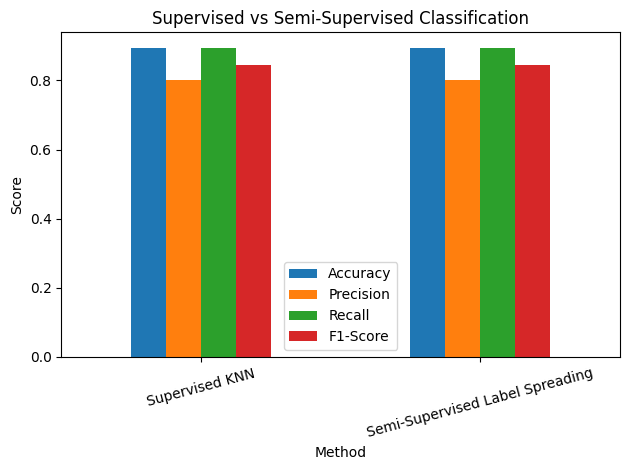

In [35]:
semi_comparison = pd.DataFrame({
    "Method": [
        "Supervised KNN",
        "Semi-Supervised Label Spreading"
    ],
    "Accuracy": [
        knn_accuracy,
        semi_accuracy
    ],
    "Precision": [
        knn_precision,
        semi_precision
    ],
    "Recall": [
        knn_recall,
        semi_recall
    ],
    "F1-Score": [
        knn_f1,
        semi_f1
    ]
})

print(semi_comparison)

semi_comparison.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "Semi_Supervised",
        "supervised_vs_semi_supervised.csv"
    ),
    index=False
)

plt.figure(figsize=(10, 6))

semi_comparison.set_index(
    "Method"
)[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(kind="bar")

plt.ylabel("Score")
plt.title("Supervised vs Semi-Supervised Classification")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Semi_Supervised",
        "supervised_vs_semi_supervised.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
#TASK 9 — DIMENSIONALITY REDUCTION

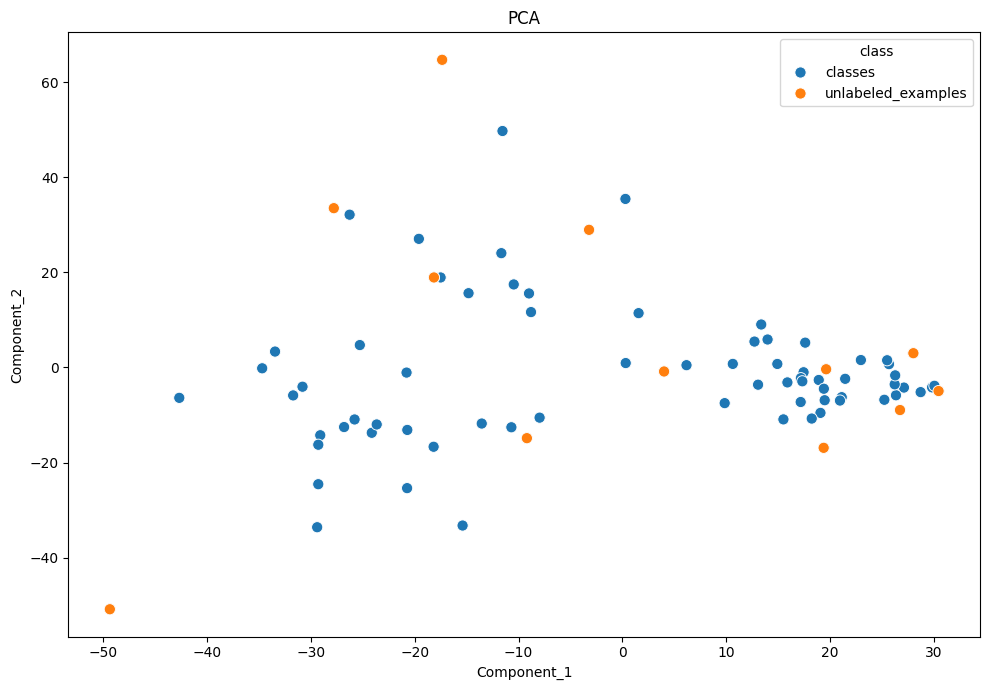

In [37]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "Component_1": X_pca[:, 0],
    "Component_2": X_pca[:, 1],
    "class": data["class"]
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="Component_1",
    y="Component_2",
    hue="class",
    palette="tab10",
    s=65
)

plt.title("PCA")
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Dimensionality_Reduction",
        "PCA.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

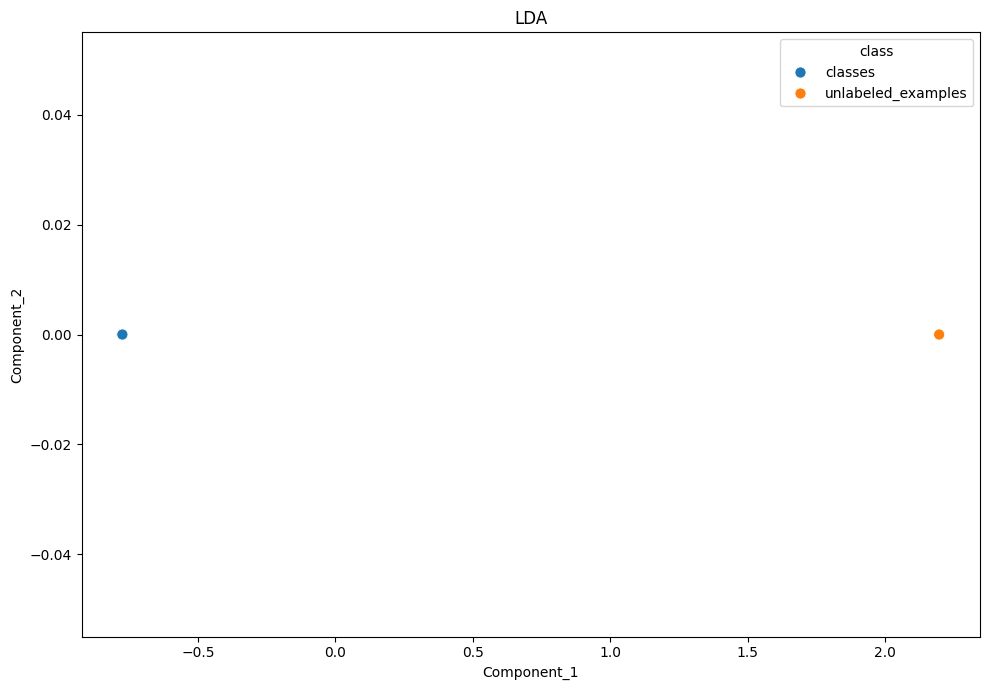

In [38]:
lda_components = min(
    2,
    n_classes - 1
)

lda = LinearDiscriminantAnalysis(
    n_components=lda_components
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

if lda_components == 1:
    X_lda = np.column_stack([
        X_lda[:, 0],
        np.zeros(len(X_lda))
    ])

lda_df = pd.DataFrame({
    "Component_1": X_lda[:, 0],
    "Component_2": X_lda[:, 1],
    "class": data["class"]
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=lda_df,
    x="Component_1",
    y="Component_2",
    hue="class",
    palette="tab10",
    s=65
)

plt.title("LDA")
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Dimensionality_Reduction",
        "LDA.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

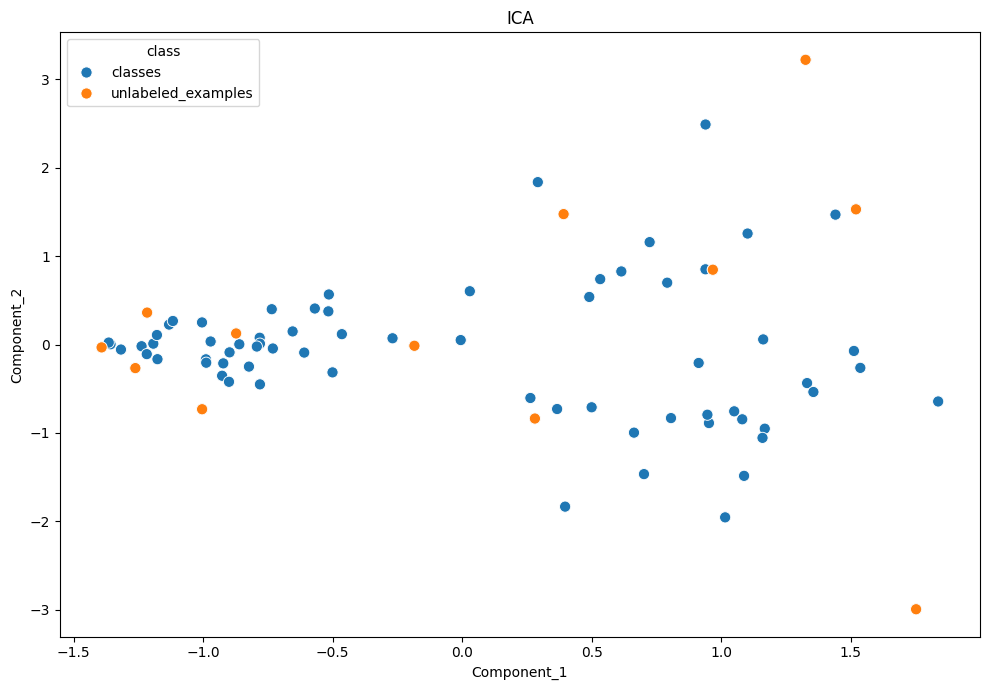

In [39]:
ica = FastICA(
    n_components=2,
    random_state=42,
    max_iter=1000,
    whiten="unit-variance"
)

X_ica = ica.fit_transform(
    X_scaled
)

ica_df = pd.DataFrame({
    "Component_1": X_ica[:, 0],
    "Component_2": X_ica[:, 1],
    "class": data["class"]
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=ica_df,
    x="Component_1",
    y="Component_2",
    hue="class",
    palette="tab10",
    s=65
)

plt.title("ICA")
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Dimensionality_Reduction",
        "ICA.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

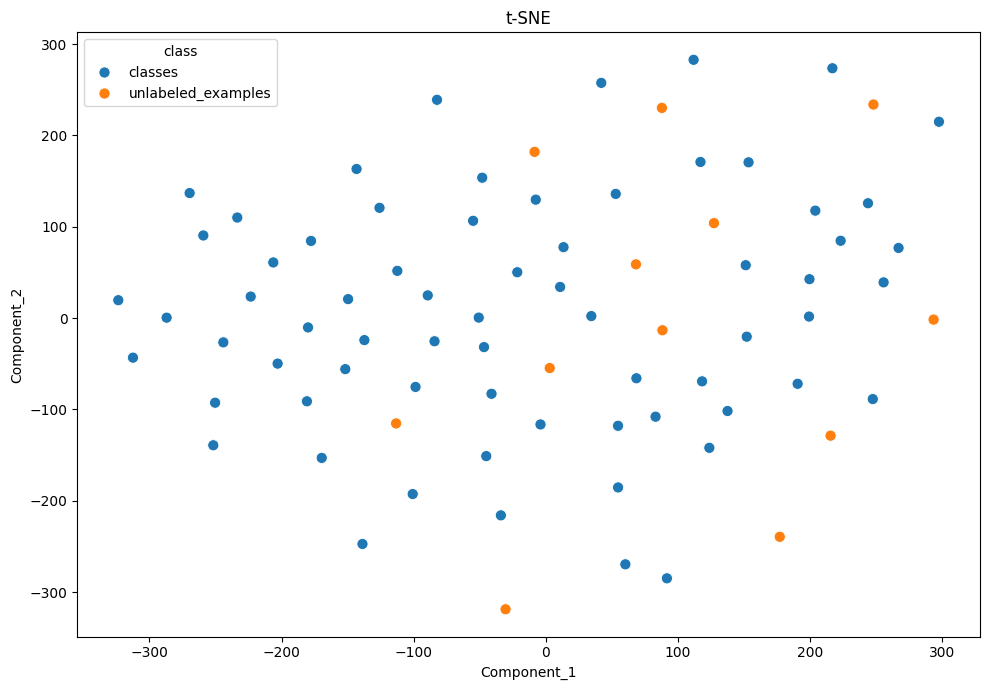

In [40]:
tsne_perplexity = min(
    30,
    max(5, (len(X_scaled) - 1) // 3)
)

tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(
    X_scaled
)

tsne_df = pd.DataFrame({
    "Component_1": X_tsne[:, 0],
    "Component_2": X_tsne[:, 1],
    "class": data["class"]
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=tsne_df,
    x="Component_1",
    y="Component_2",
    hue="class",
    palette="tab10",
    s=65
)

plt.title("t-SNE")
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Dimensionality_Reduction",
        "tSNE.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
dimensionality_results = pd.DataFrame({
    "class": data["class"],
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "LDA_1": X_lda[:, 0],
    "LDA_2": X_lda[:, 1],
    "ICA_1": X_ica[:, 0],
    "ICA_2": X_ica[:, 1],
    "tSNE_1": X_tsne[:, 0],
    "tSNE_2": X_tsne[:, 1]
})

dimensionality_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "Dimensionality_Reduction",
        "dimensionality_reduction_coordinates.csv"
    ),
    index=False
)

In [42]:
#TASK 10 — COMPLETE PATTERN-RECOGNITION SYSTEM

In [43]:
complete_scaler = StandardScaler()

X_complete = complete_scaler.fit_transform(
    X
)

X_train_complete, X_test_complete, y_train_complete, y_test_complete = train_test_split(
    X_complete,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

complete_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

complete_gnb = GaussianNB()

complete_knn.fit(
    X_train_complete,
    y_train_complete
)

complete_gnb.fit(
    X_train_complete,
    y_train_complete
)

complete_knn_pred = complete_knn.predict(
    X_test_complete
)

complete_gnb_pred = complete_gnb.predict(
    X_test_complete
)

complete_results = pd.DataFrame({
    "Classifier": [
        "KNN",
        "Gaussian Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test_complete, complete_knn_pred),
        accuracy_score(y_test_complete, complete_gnb_pred)
    ],
    "Precision": [
        precision_score(
            y_test_complete,
            complete_knn_pred,
            average="weighted",
            zero_division=0
        ),
        precision_score(
            y_test_complete,
            complete_gnb_pred,
            average="weighted",
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_test_complete,
            complete_knn_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_test_complete,
            complete_gnb_pred,
            average="weighted",
            zero_division=0
        )
    ],
    "F1-Score": [
        f1_score(
            y_test_complete,
            complete_knn_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test_complete,
            complete_gnb_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

print(complete_results)

complete_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "Complete_System",
        "complete_system_results.csv"
    ),
    index=False
)

joblib.dump(
    complete_scaler,
    os.path.join(
        OUTPUT_PATH,
        "Complete_System",
        "scaler.pkl"
    )
)

joblib.dump(
    complete_knn,
    os.path.join(
        OUTPUT_PATH,
        "Complete_System",
        "knn.pkl"
    )
)

joblib.dump(
    complete_gnb,
    os.path.join(
        OUTPUT_PATH,
        "Complete_System",
        "gaussian_nb.pkl"
    )
)

             Classifier  Accuracy  Precision    Recall  F1-Score
0                   KNN  0.894737   0.800554  0.894737  0.845029
1  Gaussian Naive Bayes  0.842105   0.795322  0.842105  0.818045


['/content/drive/MyDrive/CSE25029_Assignment_4_Output/Complete_System/gaussian_nb.pkl']

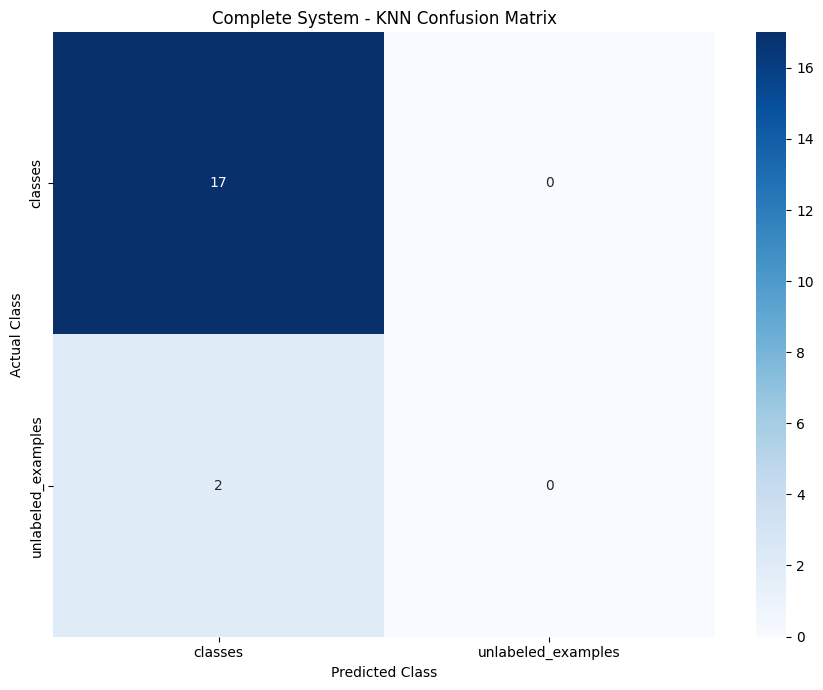

In [44]:
cm_complete_knn = confusion_matrix(
    y_test_complete,
    complete_knn_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_complete_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Complete System - KNN Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Complete_System",
        "knn_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

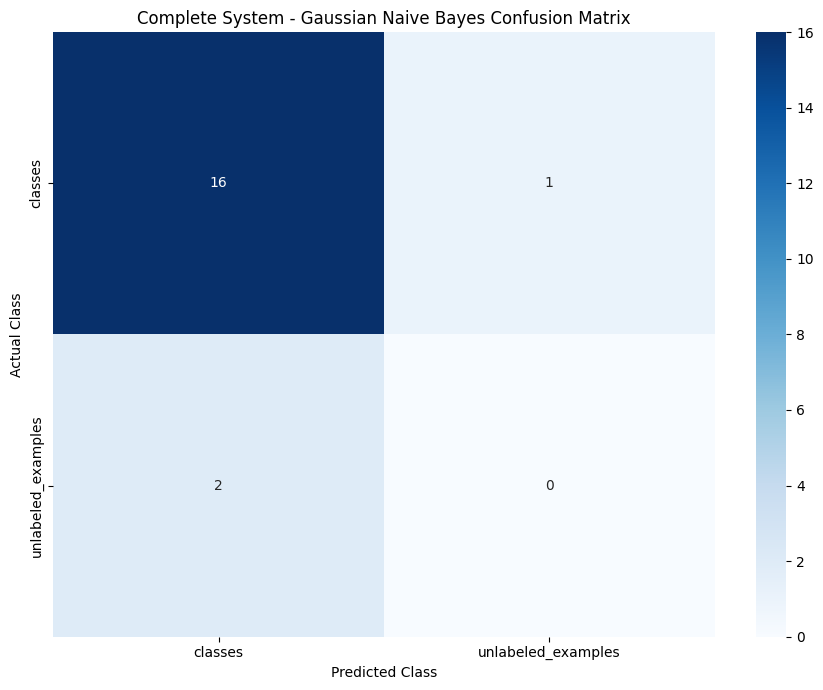

In [45]:
cm_complete_gnb = confusion_matrix(
    y_test_complete,
    complete_gnb_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_complete_gnb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Complete System - Gaussian Naive Bayes Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "Complete_System",
        "gaussian_nb_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
overall_results = pd.DataFrame({
    "Method": [
        "K-Means",
        "K-Medoids",
        "GMM",
        "Gaussian Naive Bayes",
        "KNN",
        "ANN",
        "Semi-Supervised Label Spreading"
    ],
    "Accuracy": [
        np.nan,
        np.nan,
        np.nan,
        gnb_accuracy,
        best_accuracy,
        ann_accuracy,
        semi_accuracy
    ],
    "Precision": [
        np.nan,
        np.nan,
        np.nan,
        gnb_precision,
        precision_score(
            y_test,
            best_knn_predictions,
            average="weighted",
            zero_division=0
        ),
        ann_precision,
        semi_precision
    ],
    "Recall": [
        np.nan,
        np.nan,
        np.nan,
        gnb_recall,
        recall_score(
            y_test,
            best_knn_predictions,
            average="weighted",
            zero_division=0
        ),
        ann_recall,
        semi_recall
    ],
    "F1-Score": [
        np.nan,
        np.nan,
        np.nan,
        gnb_f1,
        f1_score(
            y_test,
            best_knn_predictions,
            average="weighted",
            zero_division=0
        ),
        ann_f1,
        semi_f1
    ],
    "ARI": [
        kmeans_ari,
        kmedoids_ari,
        gmm_ari,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],
    "NMI": [
        kmeans_nmi,
        kmedoids_nmi,
        gmm_nmi,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ]
})

print(overall_results)

overall_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "overall_method_comparison.csv"
    ),
    index=False
)

                            Method  Accuracy  Precision    Recall  F1-Score  \
0                          K-Means       NaN        NaN       NaN       NaN   
1                        K-Medoids       NaN        NaN       NaN       NaN   
2                              GMM       NaN        NaN       NaN       NaN   
3             Gaussian Naive Bayes  0.842105   0.795322  0.842105  0.818045   
4                              KNN  0.894737   0.800554  0.894737  0.845029   
5                              ANN  0.473684   0.732057  0.473684  0.575188   
6  Semi-Supervised Label Spreading  0.894737   0.800554  0.894737  0.845029   

        ARI       NMI  
0 -0.006865  0.001446  
1 -0.006729  0.000187  
2 -0.006865  0.001446  
3       NaN       NaN  
4       NaN       NaN  
5       NaN       NaN  
6       NaN       NaN  


<Figure size 1200x700 with 0 Axes>

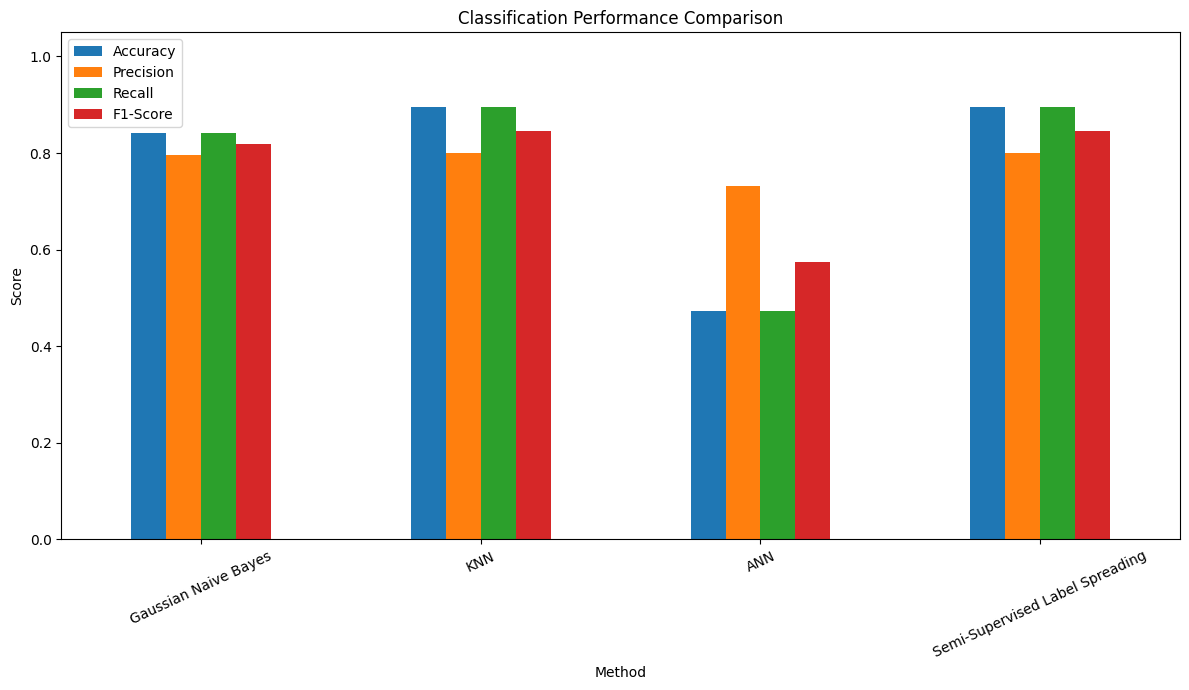

In [47]:
classification_plot = overall_results.dropna(
    subset=["Accuracy"]
).set_index("Method")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

plt.figure(figsize=(12, 7))

classification_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.ylabel("Score")
plt.xlabel("Method")
plt.title("Classification Performance Comparison")
plt.xticks(rotation=25)
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "overall_classification_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x600 with 0 Axes>

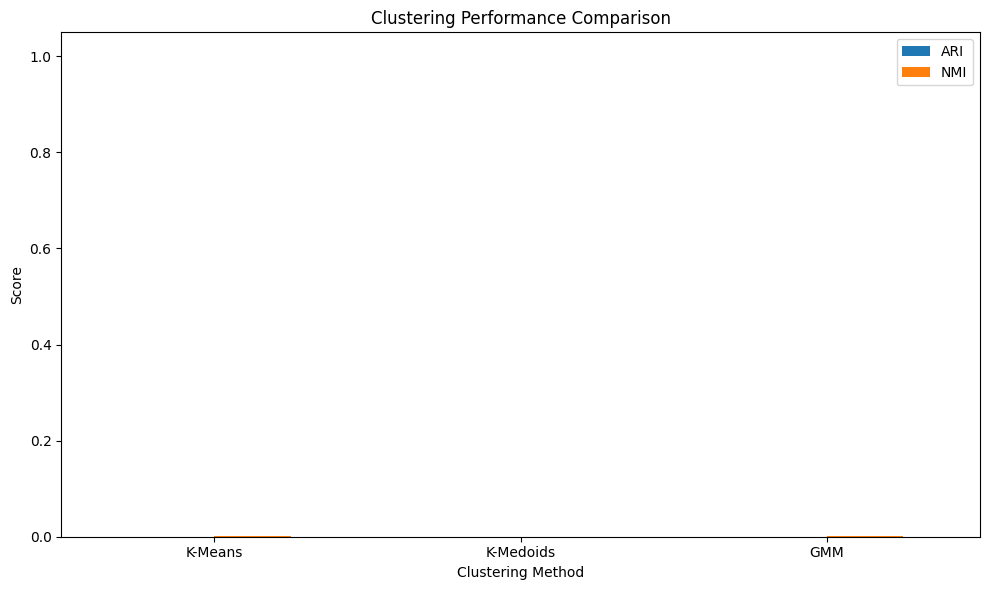

In [48]:
clustering_plot = pd.DataFrame({
    "Method": [
        "K-Means",
        "K-Medoids",
        "GMM"
    ],
    "ARI": [
        kmeans_ari,
        kmedoids_ari,
        gmm_ari
    ],
    "NMI": [
        kmeans_nmi,
        kmedoids_nmi,
        gmm_nmi
    ]
})

plt.figure(figsize=(10, 6))

clustering_plot.set_index(
    "Method"
)[
    ["ARI", "NMI"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")
plt.xlabel("Clustering Method")
plt.title("Clustering Performance Comparison")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "clustering_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

clustering_plot.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "clustering_comparison.csv"
    ),
    index=False
)

In [49]:
reports = {
    "Gaussian_Naive_Bayes": classification_report(
        y_test,
        gnb_predictions,
        target_names=class_names,
        zero_division=0
    ),
    "Best_KNN": classification_report(
        y_test,
        best_knn_predictions,
        target_names=class_names,
        zero_division=0
    ),
    "ANN": classification_report(
        y_test,
        ann_predictions,
        target_names=class_names,
        zero_division=0
    ),
    "Semi_Supervised": classification_report(
        y_test,
        semi_predictions,
        target_names=class_names,
        zero_division=0
    )
}

for name, report in reports.items():
    with open(
        os.path.join(
            OUTPUT_PATH,
            f"{name}_classification_report.txt"
        ),
        "w"
    ) as file:
        file.write(report)

In [50]:
final_summary = {
    "Dataset_Size": len(data),
    "Number_of_Classes": n_classes,
    "Classes": ", ".join(class_names),
    "Feature_Count": X.shape[1],
    "Training_Size": len(X_train),
    "Testing_Size": len(X_test),
    "Best_KNN_K": best_k,
    "Best_KNN_Accuracy": best_accuracy,
    "Gaussian_NB_Accuracy": gnb_accuracy,
    "ANN_Accuracy": ann_accuracy,
    "Semi_Supervised_Accuracy": semi_accuracy,
    "KMeans_ARI": kmeans_ari,
    "KMeans_NMI": kmeans_nmi,
    "KMedoids_ARI": kmedoids_ari,
    "KMedoids_NMI": kmedoids_nmi,
    "GMM_ARI": gmm_ari,
    "GMM_NMI": gmm_nmi
}

final_summary_df = pd.DataFrame(
    [final_summary]
)

final_summary_df.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "FINAL_SUMMARY.csv"
    ),
    index=False
)

print(final_summary_df.T)

                                                    0
Dataset_Size                                       92
Number_of_Classes                                   2
Classes                   classes, unlabeled_examples
Feature_Count                                    8155
Training_Size                                      73
Testing_Size                                       19
Best_KNN_K                                          2
Best_KNN_Accuracy                            0.894737
Gaussian_NB_Accuracy                         0.842105
ANN_Accuracy                                 0.473684
Semi_Supervised_Accuracy                     0.894737
KMeans_ARI                                  -0.006865
KMeans_NMI                                   0.001446
KMedoids_ARI                                -0.006729
KMedoids_NMI                                 0.000187
GMM_ARI                                     -0.006865
GMM_NMI                                      0.001446


In [51]:
all_files = []

for root, dirs, files in os.walk(OUTPUT_PATH):
    for file in files:
        full_path = os.path.join(root, file)
        all_files.append(
            os.path.relpath(
                full_path,
                OUTPUT_PATH
            )
        )

all_files = sorted(all_files)

print("Total output files:", len(all_files))

for file in all_files:
    print(file)

print("\nAll outputs saved successfully to:")
print(OUTPUT_PATH)

Total output files: 58
ANN/ann_confusion_matrix.png
ANN/ann_model.pkl
ANN/ann_results.csv
ANN_classification_report.txt
Bayesian/bayesian_confusion_matrix.png
Bayesian/gaussian_naive_bayes_model.pkl
Bayesian/gaussian_naive_bayes_results.csv
Best_KNN_classification_report.txt
Complete_System/complete_system_results.csv
Complete_System/gaussian_nb.pkl
Complete_System/gaussian_nb_confusion_matrix.png
Complete_System/knn.pkl
Complete_System/knn_confusion_matrix.png
Complete_System/scaler.pkl
Dimensionality_Reduction/ICA.png
Dimensionality_Reduction/LDA.png
Dimensionality_Reduction/PCA.png
Dimensionality_Reduction/PCA_2D.png
Dimensionality_Reduction/dimensionality_reduction_coordinates.csv
Dimensionality_Reduction/tSNE.png
FINAL_SUMMARY.csv
GMM/gmm_clusters.png
GMM/gmm_model.pkl
GMM/gmm_results.csv
GMM/kmeans_vs_gmm.csv
GMM/kmeans_vs_gmm.png
Gaussian_Naive_Bayes_classification_report.txt
KMeans/kmeans_assignments.csv
KMeans/kmeans_centroids.npy
KMeans/kmeans_clusters_centroids.png
KMeans/km